In [3]:
import numpy as np
import pandas as pd
import requests
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time

In [24]:
cities_url = 'https://car-catalog-gateway-in.c24.tech/website/v1/cities'

In [25]:
cars_url = 'https://car-catalog-gateway-in.c24.tech/listing/v1/buy-used-car'

In [26]:
headers = {
                'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36',
                'content-type':'application/json'
              }

payload = {
            'searchFilter':[],
            'cityId':'',
            'sort':'bestmatch',
            'size':20,
            'filterVersion':4
          }

In [27]:
cities_response = requests.get(cities_url, headers = headers)
cars_response = requests.post(cars_url, json=payload, headers=headers)

In [28]:
cities_response

<Response [200]>

In [29]:
cars_response

<Response [200]>

In [62]:
cities_data = cities_response.json()
cars_data = cars_response.json()

In [97]:
cities_data[:5]

[{'cityName': 'Delhi NCR',
  'cityId': 1,
  'url': 'buy-used-cars-delhi-ncr/',
  'featured': True,
  'availableBrands': [{'make': 'maruti',
    'url': 'buy-used-maruti-cars/',
    'count': 1869},
   {'make': 'hyundai', 'url': 'buy-used-hyundai-cars/', 'count': 1314},
   {'make': 'honda', 'url': 'buy-used-honda-cars/', 'count': 586},
   {'make': 'tata', 'url': 'buy-used-tata-cars/', 'count': 564},
   {'make': 'mahindra', 'url': 'buy-used-mahindra-cars/', 'count': 365},
   {'make': 'kia', 'url': 'buy-used-kia-cars/', 'count': 261},
   {'make': 'toyota', 'url': 'buy-used-toyota-cars/', 'count': 209},
   {'make': 'ford', 'url': 'buy-used-ford-cars/', 'count': 169},
   {'make': 'renault', 'url': 'buy-used-renault-cars/', 'count': 164},
   {'make': 'mg', 'url': 'buy-used-mg-cars/', 'count': 138},
   {'make': 'volkswagen', 'url': 'buy-used-volkswagen-cars/', 'count': 92},
   {'make': 'nissan', 'url': 'buy-used-nissan-cars/', 'count': 75},
   {'make': 'skoda', 'url': 'buy-used-skoda-cars/', 'c

In [122]:
cities = [(city['cityId'], city['cityName']) for city in cities_data]
cities

[(1, 'Delhi NCR'),
 (8623, 'Chandigarh Tricity'),
 (2, 'New Delhi'),
 (4, 'Kurukshetra'),
 (7, 'Palwal'),
 (28, 'Jhajjar'),
 (29, 'Rewari'),
 (36, 'Bahadurgarh'),
 (38, 'Panipat'),
 (40, 'Hisar'),
 (42, 'Fatehabad'),
 (50, 'Jind'),
 (53, 'Bhiwani'),
 (62, 'Sonipat'),
 (64, 'Karnal'),
 (73, 'Ambala'),
 (75, 'Yamuna Nagar'),
 (135, 'Aligarh'),
 (144, 'Moradabad'),
 (153, 'Bulandshahar'),
 (158, 'Hapur'),
 (162, 'Mainpuri'),
 (173, 'Kanpur'),
 (191, 'Varanasi'),
 (213, 'Allahabad'),
 (246, 'Baraut'),
 (280, 'Gorakhpur'),
 (283, 'Ambedkar Nagar'),
 (291, 'Barabanki'),
 (314, 'Raibareli'),
 (359, 'Bareilly'),
 (369, 'Saharanpur'),
 (404, 'Meerut'),
 (425, 'Muzaffarnagar'),
 (508, 'Jhansi'),
 (553, 'Mathura'),
 (648, 'Zirakpur'),
 (650, 'Mohali'),
 (664, 'Patiala'),
 (684, 'Amritsar'),
 (692, 'Jalandhar'),
 (734, 'Bathinda'),
 (776, 'Murshidabad'),
 (778, 'Howrah'),
 (779, 'Hooghly'),
 (780, 'Asansol'),
 (807, 'Burdwan'),
 (810, 'Durgapur'),
 (828, 'Kharagpur'),
 (982, 'Siliguri'),
 (1057, '

In [124]:
df_city = pd.DataFrame(cities,columns = ('city_id','city_name'))
df_city

,city_id,city_name
0,1,Delhi NCR
1,8623,Chandigarh Tricity
2,2,New Delhi
3,4,Kurukshetra
4,7,Palwal
...,...,...
201,666,Ludhiana
202,33,Rohtak
203,1606,Rajkot
204,1674,Vadodara


In [112]:
cars_data

{'content': [{'appointmentId': '10161906707',
   'maskedRegNum': 'HR26**5418',
   'locationCode': 'IN_CAR_CC_5_FC_3',
   'locationId': 2303,
   'cityCode': 'CC_5',
   'cityId': 5,
   'listingPrice': 324000,
   'cumulativeListingPrice': 324000,
   'originalPrice': 371641,
   'onRoadPrice': 0,
   'geoCoordinates': {'lat': 28.39229885, 'lon': 77.06644309, 'valid': True},
   'discount': 47641.0,
   'status': 'AVAILABLE',
   'listing': 'LISTED',
   'carName': 'Maruti New Wagon-R',
   'make': 'Maruti',
   'model': 'New Wagon-R',
   'variant': 'VXI (O) 1.2',
   'year': 2019,
   'transmissionType': {'value': 'Manual', 'display': 'Manual'},
   'bodyType': 'Hatchback',
   'fuelType': 'Petrol',
   'ownership': 1,
   'registrationDate': '1572566400000',
   'cityRto': 'HR26',
   'color': 'Grey',
   'odometer': {'value': 74374, 'display': '74,374 km'},
   'listingImage': {'key': 'Exterior + Diagonal + FRONT + RHS',
    'checkpoint': 'Right Front Diagonal',
    'category': 'Exterior',
    'label': 'R

In [114]:
 cars = data.get("content", [])

In [115]:
cars

[{'appointmentId': '10161906707',
  'maskedRegNum': 'HR26**5418',
  'locationCode': 'IN_CAR_CC_5_FC_3',
  'locationId': 2303,
  'cityCode': 'CC_5',
  'cityId': 5,
  'listingPrice': 324000,
  'cumulativeListingPrice': 324000,
  'originalPrice': 371641,
  'onRoadPrice': 0,
  'geoCoordinates': {'lat': 28.39229885, 'lon': 77.06644309, 'valid': True},
  'discount': 47641.0,
  'status': 'AVAILABLE',
  'listing': 'LISTED',
  'carName': 'Maruti New Wagon-R',
  'make': 'Maruti',
  'model': 'New Wagon-R',
  'variant': 'VXI (O) 1.2',
  'year': 2019,
  'transmissionType': {'value': 'Manual', 'display': 'Manual'},
  'bodyType': 'Hatchback',
  'fuelType': 'Petrol',
  'ownership': 1,
  'registrationDate': '1572566400000',
  'cityRto': 'HR26',
  'color': 'Grey',
  'odometer': {'value': 74374, 'display': '74,374 km'},
  'listingImage': {'key': 'Exterior + Diagonal + FRONT + RHS',
   'checkpoint': 'Right Front Diagonal',
   'category': 'Exterior',
   'label': 'Right Front Diagonal',
   'uri': 'https://m

In [162]:
max_cars = 1000
all_cars = []
search_after = None

while len(all_cars) < max_cars:

    if search_after:
        payload["searchAfter"] = search_after

    response = requests.post(url, json=payload, headers=headers)
    
    data = response.json()
    cars = data.get("content", [])

    if not cars:
        print("No more cars returned by API.")
        break

    for car in cars:
        car_name = car.get("carName")
        color = car.get('color')
        city_id = car.get("cityId")
        listing_price = car.get("listingPrice")
        original_price = car.get('originalPrice')
        discount = car.get('discount')
        status = car.get('status')
        year = car.get('year')
        transmission = car.get('transmissionType', {})
        body_type = car.get('bodyType')
        fuel_type = car.get('fuelType')
        city_rto = car.get('cityRto')
        

        all_cars.append({
            'car_name': car_name,
            'color': color,
            'city_id': city_id,
            'listing_price': listing_price,
            'original_price': original_price,
            'discount': discount,
            'status': status,
            'year': year,
            'transmission': transmission,
            'body_type': body_type,
            'fuel_type': fuel_type,
            'city_rto': city_rto
            })

        if len(all_cars) >= max_cars:
            break

    last_car = cars[-1]
    search_after = [
        last_car["score"],
        last_car["appointmentId"]
    ]

    time.sleep(1)


In [163]:
all_cars

[{'car_name': 'Hyundai NEW I20',
  'color': 'Blue',
  'city_id': 5732,
  'listing_price': 675000,
  'original_price': 691280,
  'discount': 16280.0,
  'status': 'AVAILABLE',
  'year': 2021,
  'transmission': {'value': 'Manual', 'display': 'Manual'},
  'body_type': 'Hatchback',
  'fuel_type': 'Diesel',
  'city_rto': 'TN07'},
 {'car_name': 'Tata TIGOR',
  'color': 'Red',
  'city_id': 134,
  'listing_price': 477000,
  'original_price': 510390,
  'discount': 33390.0,
  'status': 'AVAILABLE',
  'year': 2022,
  'transmission': {'value': 'Manual', 'display': 'Manual'},
  'body_type': 'Sedan',
  'fuel_type': 'CNG',
  'city_rto': 'UP16'},
 {'car_name': 'Honda Amaze',
  'color': 'Brown',
  'city_id': 4709,
  'listing_price': 740215,
  'original_price': 755504,
  'discount': 15289.0,
  'status': 'AVAILABLE',
  'year': 2021,
  'transmission': {'value': 'Automatic', 'display': 'Auto'},
  'body_type': 'Sedan',
  'fuel_type': 'Petrol',
  'city_rto': 'KA50'},
 {'car_name': 'Hyundai i10',
  'color': 'G

In [164]:
df_cars = pd.DataFrame(all_cars)

In [165]:
df_cars

,car_name,color,city_id,listing_price,original_price,discount,status,year,transmission,body_type,fuel_type,city_rto
0,Hyundai NEW I20,Blue,5732,675000,691280,16280.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Diesel,TN07
1,Tata TIGOR,Red,134,477000,510390,33390.0,AVAILABLE,2022,"{'value': 'Manual', 'display': 'Manual'}",Sedan,CNG,UP16
2,Honda Amaze,Brown,4709,740215,755504,15289.0,AVAILABLE,2021,"{'value': 'Automatic', 'display': 'Auto'}",Sedan,Petrol,KA50
3,Hyundai i10,Grey,2378,164000,179200,15200.0,AVAILABLE,2012,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Petrol,MH02
4,Tata Tiago,Brown,2423,317652,317652,0.0,AVAILABLE,2016,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,CNG,MH12
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Hyundai Eon,Red,2378,150000,217854,67854.0,AVAILABLE,2014,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Petrol,MH03
996,Maruti Swift,Brown,3686,591000,609080,18080.0,AVAILABLE,2019,"{'value': 'Automatic', 'display': 'Auto'}",Hatchback,Diesel,TS09
997,Mahindra KUV 100 NXT,Grey,2,293766,303766,10000.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}",SUV,Petrol,DL7C
998,Hyundai Xcent,Red,2920,237644,288737,51093.0,AVAILABLE,2014,"{'value': 'Manual', 'display': 'Manual'}",Sedan,Petrol,MP04


In [166]:
Dataset = df_cars.merge(df_city[['city_name','city_id']],on = 'city_id', how = 'left')

In [167]:
Dataset

,car_name,color,city_id,listing_price,original_price,discount,status,year,transmission,body_type,fuel_type,city_rto,city_name
0,Hyundai NEW I20,Blue,5732,675000,691280,16280.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Diesel,TN07,Chennai
1,Tata TIGOR,Red,134,477000,510390,33390.0,AVAILABLE,2022,"{'value': 'Manual', 'display': 'Manual'}",Sedan,CNG,UP16,Noida
2,Honda Amaze,Brown,4709,740215,755504,15289.0,AVAILABLE,2021,"{'value': 'Automatic', 'display': 'Auto'}",Sedan,Petrol,KA50,Bangalore
3,Hyundai i10,Grey,2378,164000,179200,15200.0,AVAILABLE,2012,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Petrol,MH02,Mumbai
4,Tata Tiago,Brown,2423,317652,317652,0.0,AVAILABLE,2016,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,CNG,MH12,Pune
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Hyundai Eon,Red,2378,150000,217854,67854.0,AVAILABLE,2014,"{'value': 'Manual', 'display': 'Manual'}",Hatchback,Petrol,MH03,Mumbai
996,Maruti Swift,Brown,3686,591000,609080,18080.0,AVAILABLE,2019,"{'value': 'Automatic', 'display': 'Auto'}",Hatchback,Diesel,TS09,Hyderabad
997,Mahindra KUV 100 NXT,Grey,2,293766,303766,10000.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}",SUV,Petrol,DL7C,New Delhi
998,Hyundai Xcent,Red,2920,237644,288737,51093.0,AVAILABLE,2014,"{'value': 'Manual', 'display': 'Manual'}",Sedan,Petrol,MP04,Indore


In [168]:
Dataset.to_csv(r'C:\Users\Dileep Seepani\OneDrive\Desktop\Dataset.csv', index = False)

In [44]:
df = pd.read_csv(r"C:\Users\Siva Krishna\Downloads\Web Scraping Project Cars24.com\Dataset Updated.csv")

This is Our Data Frame Which we get from the Webscraping of Cars24.com

In [45]:
df

,car_name,color,car_segment,ownership,city_id,fitness_age,listing_price,original_price,discount,status,year,transmission,odometer,body_type,fuel_type,city_rto,wishlist_count,city_name
0,Tata Tiago,Brown,STANDARD,1,1692,15,265743,281720,15977.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}","{'value': 45332, 'display': '45,332 km'}",Hatchback,Petrol,GJ01,160.0,Ahmedabad
1,Jeep Compass,Red,STANDARD,2,2378,14,617649,630254,12605.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}","{'value': 55340, 'display': '55,340 km'}",SUV,Diesel,MH47,90.0,Mumbai
2,Volkswagen Polo,White,STANDARD,2,2423,15,461000,518479,57479.0,AVAILABLE,2017,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 61917, 'display': '61,917 km'}",Hatchback,Petrol,MH09,90.0,Pune
3,Hyundai NEW I20,Blue,STANDARD,2,5732,14,675000,691280,16280.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}","{'value': 89972, 'display': '89,972 km'}",Hatchback,Diesel,TN07,50.0,Chennai
4,KIA SONET,Red,STANDARD,1,3686,15,651700,682796,31096.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}","{'value': 47881, 'display': '47,881 km'}",SUV,Petrol,TS08,90.0,Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Honda Brio,Grey,STANDARD,1,290,15,212000,221683,9683.0,AVAILABLE,2015,"{'value': 'Manual', 'display': 'Manual'}","{'value': 71759, 'display': '71,759 km'}",Hatchback,Petrol,UP32,20.0,Lucknow
996,Honda City,Red,STANDARD,1,6,15,353000,387835,34835.0,AVAILABLE,2015,"{'value': 'Manual', 'display': 'Manual'}","{'value': 52631, 'display': '52,631 km'}",Sedan,Petrol,HR16,10.0,Faridabad
997,Hyundai Grand i10,Blue,STANDARD,2,5,15,267626,0,0.0,AVAILABLE,2014,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 47800, 'display': '47,800 km'}",Hatchback,Petrol,HR26,10.0,Gurgaon
998,Maruti Ertiga,Red,STANDARD,1,134,15,872685,930640,57955.0,AVAILABLE,2022,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 33086, 'display': '33,086 km'}",SUV,Petrol,DL4C,20.0,Noida


First We need to check the Dataset and its Columns and need to check the first 5 rows by using df.head()

In [46]:
df.head()

,car_name,color,car_segment,ownership,city_id,fitness_age,listing_price,original_price,discount,status,year,transmission,odometer,body_type,fuel_type,city_rto,wishlist_count,city_name
0,Tata Tiago,Brown,STANDARD,1,1692,15,265743,281720,15977.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}","{'value': 45332, 'display': '45,332 km'}",Hatchback,Petrol,GJ01,160.0,Ahmedabad
1,Jeep Compass,Red,STANDARD,2,2378,14,617649,630254,12605.0,AVAILABLE,2017,"{'value': 'Manual', 'display': 'Manual'}","{'value': 55340, 'display': '55,340 km'}",SUV,Diesel,MH47,90.0,Mumbai
2,Volkswagen Polo,White,STANDARD,2,2423,15,461000,518479,57479.0,AVAILABLE,2017,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 61917, 'display': '61,917 km'}",Hatchback,Petrol,MH09,90.0,Pune
3,Hyundai NEW I20,Blue,STANDARD,2,5732,14,675000,691280,16280.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}","{'value': 89972, 'display': '89,972 km'}",Hatchback,Diesel,TN07,50.0,Chennai
4,KIA SONET,Red,STANDARD,1,3686,15,651700,682796,31096.0,AVAILABLE,2021,"{'value': 'Manual', 'display': 'Manual'}","{'value': 47881, 'display': '47,881 km'}",SUV,Petrol,TS08,90.0,Hyderabad


In the Same way Last 5 rows by using df.tail

In [47]:
df.tail()

,car_name,color,car_segment,ownership,city_id,fitness_age,listing_price,original_price,discount,status,year,transmission,odometer,body_type,fuel_type,city_rto,wishlist_count,city_name
995,Honda Brio,Grey,STANDARD,1,290,15,212000,221683,9683.0,AVAILABLE,2015,"{'value': 'Manual', 'display': 'Manual'}","{'value': 71759, 'display': '71,759 km'}",Hatchback,Petrol,UP32,20.0,Lucknow
996,Honda City,Red,STANDARD,1,6,15,353000,387835,34835.0,AVAILABLE,2015,"{'value': 'Manual', 'display': 'Manual'}","{'value': 52631, 'display': '52,631 km'}",Sedan,Petrol,HR16,10.0,Faridabad
997,Hyundai Grand i10,Blue,STANDARD,2,5,15,267626,0,0.0,AVAILABLE,2014,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 47800, 'display': '47,800 km'}",Hatchback,Petrol,HR26,10.0,Gurgaon
998,Maruti Ertiga,Red,STANDARD,1,134,15,872685,930640,57955.0,AVAILABLE,2022,"{'value': 'Automatic', 'display': 'Auto'}","{'value': 33086, 'display': '33,086 km'}",SUV,Petrol,DL4C,20.0,Noida
999,Hyundai Xcent,Silver,STANDARD,1,5,15,209000,254394,45394.0,AVAILABLE,2014,"{'value': 'Manual', 'display': 'Manual'}","{'value': 80611, 'display': '80,611 km'}",Sedan,Petrol,HR13,20.0,Gurgaon


Check the complete details about Datasets and it's columns like Null Count and Data types

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   car_name        1000 non-null   object 
 1   color           1000 non-null   object 
 2   car_segment     1000 non-null   object 
 3   ownership       1000 non-null   int64  
 4   city_id         1000 non-null   int64  
 5   fitness_age     1000 non-null   int64  
 6   listing_price   1000 non-null   int64  
 7   original_price  1000 non-null   int64  
 8   discount        1000 non-null   float64
 9   status          1000 non-null   object 
 10  year            1000 non-null   int64  
 11  transmission    1000 non-null   object 
 12  odometer        1000 non-null   object 
 13  body_type       1000 non-null   object 
 14  fuel_type       1000 non-null   object 
 15  city_rto        1000 non-null   object 
 16  wishlist_count  972 non-null    float64
 17  city_name       998 non-null    ob

We need to check the Normalized Stastics of the Dataset

In [49]:
df.describe()

,ownership,city_id,fitness_age,listing_price,original_price,discount,year,wishlist_count
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,972.000000
mean,1.291000,2534.312000,14.672000,4.449236e+05,4.560157e+05,59432.616000,2017.938000,97.407407
std,0.512427,2065.289313,0.782962,2.450832e+05,3.100657e+05,69146.799826,3.019482,99.056656
min,1.000000,2.000000,10.000000,9.600000e+04,0.000000e+00,0.000000,2011.000000,10.000000
25%,1.000000,769.000000,15.000000,2.790278e+05,2.804218e+05,18696.500000,2016.000000,30.000000
50%,1.000000,2378.000000,15.000000,3.885305e+05,4.113180e+05,43116.500000,2018.000000,60.000000
75%,2.000000,4709.000000,15.000000,5.602500e+05,6.013218e+05,76974.500000,2020.000000,120.000000
max,3.000000,8184.000000,15.000000,3.240000e+06,3.824462e+06,709046.000000,2025.000000,810.000000


In [50]:
df.describe().all()

ownership          True
city_id            True
fitness_age        True
listing_price      True
original_price    False
discount          False
year               True
wishlist_count     True
dtype: bool

To check the Null Values of the Dataset Columns

In [51]:
df.isnull().sum()  

car_name           0
color              0
car_segment        0
ownership          0
city_id            0
fitness_age        0
listing_price      0
original_price     0
discount           0
status             0
year               0
transmission       0
odometer           0
body_type          0
fuel_type          0
city_rto           0
wishlist_count    28
city_name          2
dtype: int64

We got the Percentage of Null values in different columns, We had a condition if we has less than 5% of null values in a column, we can ignore it

In [52]:
(df.isnull().sum()/len(df))*100

car_name          0.0
color             0.0
car_segment       0.0
ownership         0.0
city_id           0.0
fitness_age       0.0
listing_price     0.0
original_price    0.0
discount          0.0
status            0.0
year              0.0
transmission      0.0
odometer          0.0
body_type         0.0
fuel_type         0.0
city_rto          0.0
wishlist_count    2.8
city_name         0.2
dtype: float64

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df[df.duplicated()]

,car_name,color,car_segment,ownership,city_id,fitness_age,listing_price,original_price,discount,status,year,transmission,odometer,body_type,fuel_type,city_rto,wishlist_count,city_name


In [95]:
duplicate_percentage = df.duplicated().sum() * 100 / len(df)
print(round(duplicate_percentage, 2), "%")

0.0 %


In [53]:
df.columns

Index(['car_name', 'color', 'car_segment', 'ownership', 'city_id',
       'fitness_age', 'listing_price', 'original_price', 'discount', 'status',
       'year', 'transmission', 'odometer', 'body_type', 'fuel_type',
       'city_rto', 'wishlist_count', 'city_name'],
      dtype='object')

In [54]:
print(f"\nUnique Values per Column:")
print(df.nunique())


Unique Values per Column:
car_name          117
color              12
car_segment         2
ownership           3
city_id            24
fitness_age         4
listing_price     792
original_price    884
discount          862
status              1
year               15
transmission        2
odometer          996
body_type           3
fuel_type           3
city_rto          238
wishlist_count     52
city_name          23
dtype: int64


In [21]:
Q1 = print("Q1",df['listing_price'].quantile (0.25))
Q2 = print("Q2",df['listing_price'].quantile (0.50))
Q3 = print("Q3",df['listing_price'].quantile (0.75))

Q1 270800.0
Q2 385500.0
Q3 558070.0


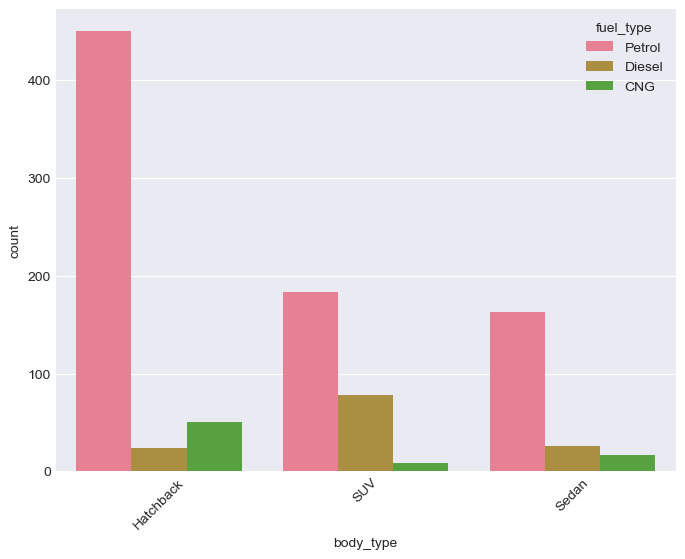

In [87]:
plt.figure(figsize=(8,6))
sns.countplot(x='body_type', hue='fuel_type', data=df)
plt.xticks(rotation=45)
plt.show()

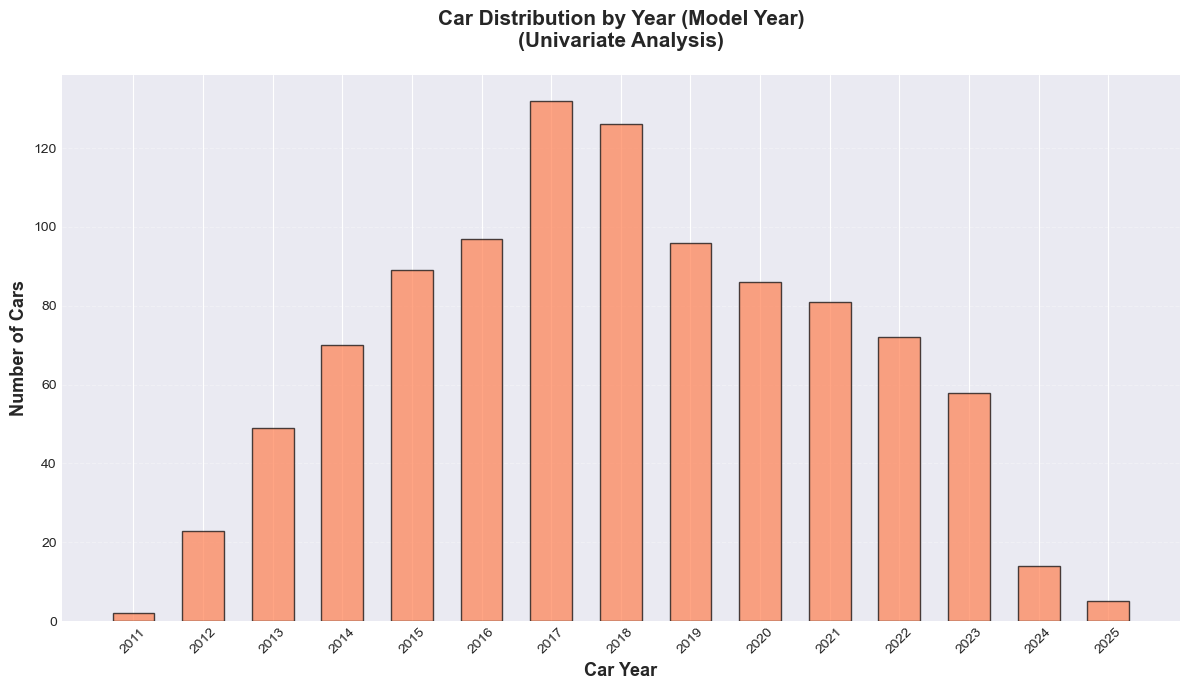

In [55]:
plt.figure(figsize=(12, 7))
year_counts = df['year'].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color='coral', edgecolor='black', alpha=0.7, width=0.6)
plt.xlabel('Car Year', fontsize=13, fontweight='bold')
plt.ylabel('Number of Cars', fontsize=13, fontweight='bold')
plt.title('Car Distribution by Year (Model Year)\n(Univariate Analysis)', fontsize=15, fontweight='bold', pad=20)
plt.grid(alpha=0.3, axis='y', linestyle='--')
plt.xticks(range(2011, 2026, 1), rotation=45)
plt.tight_layout()
plt.show()

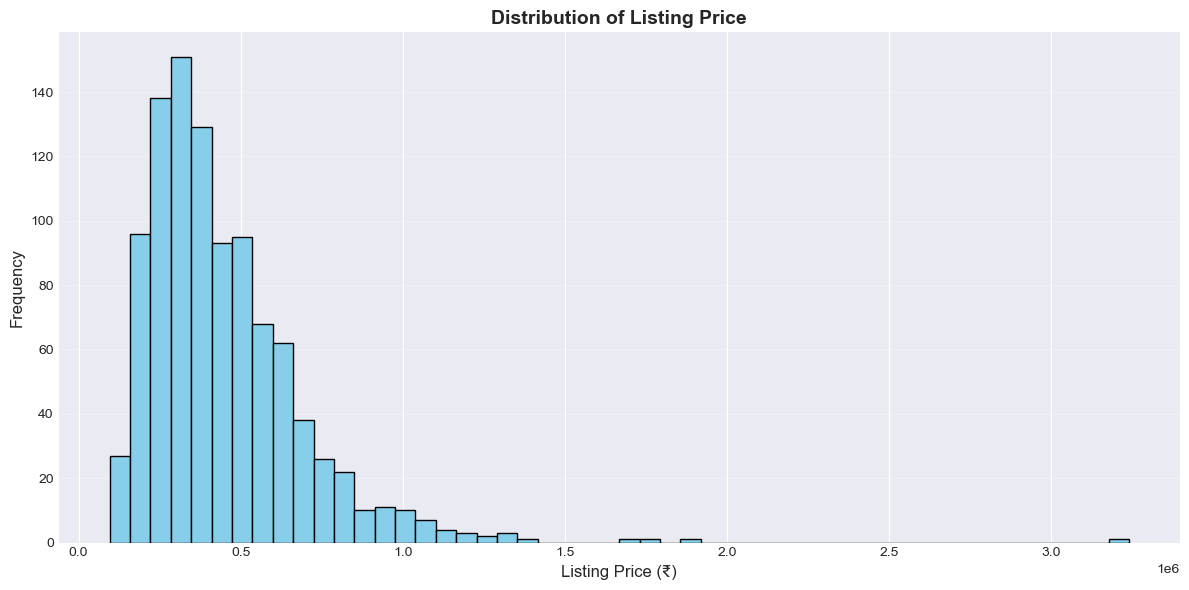

In [59]:
plt.figure(figsize=(12, 6))
plt.hist(df['listing_price'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Listing Price (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Listing Price', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

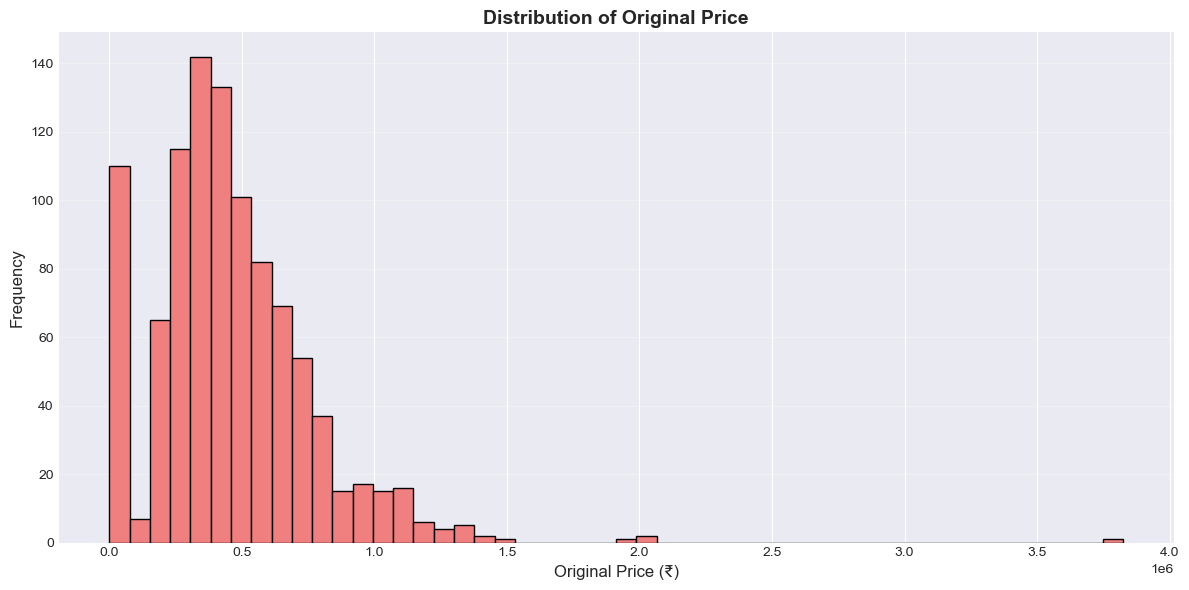

In [60]:
plt.figure(figsize=(12, 6))
plt.hist(df['original_price'], bins=50, color='lightcoral', edgecolor='black')
plt.xlabel('Original Price (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Original Price', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

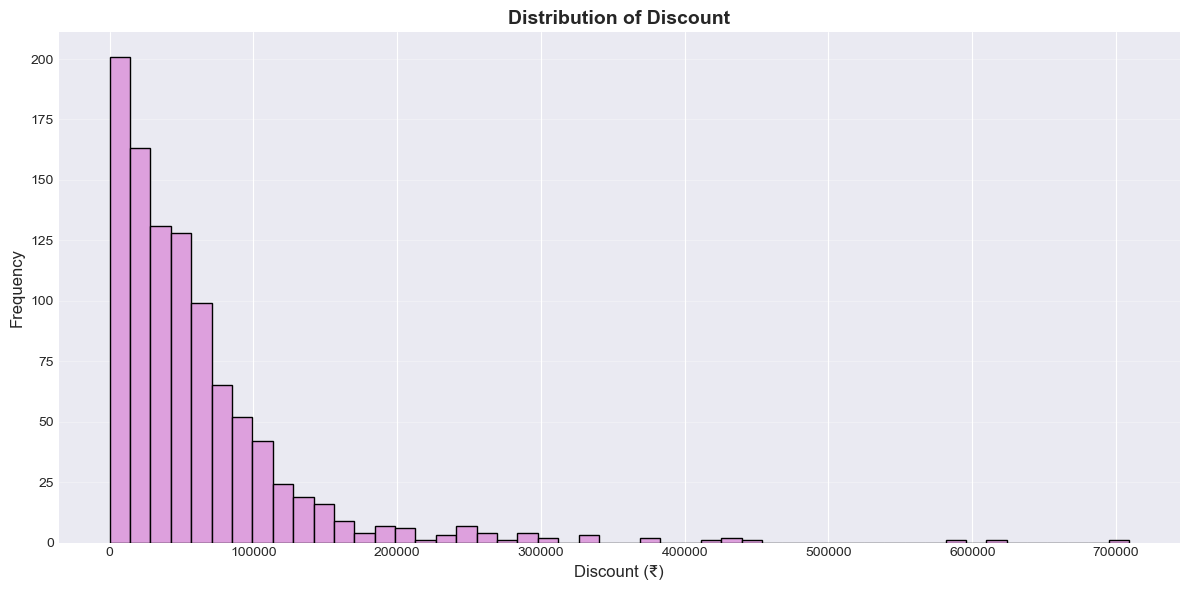

In [61]:
plt.figure(figsize=(12, 6))
plt.hist(df['discount'], bins=50, color='plum', edgecolor='black')
plt.xlabel('Discount (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Discount', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

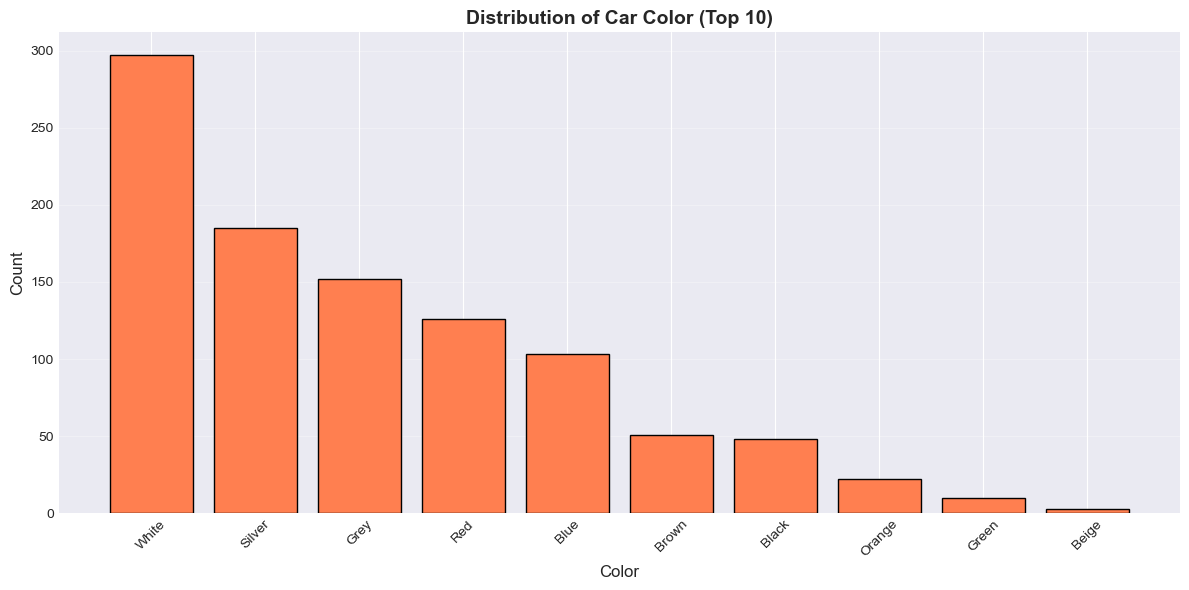

In [62]:
plt.figure(figsize=(12, 6))
color_counts = df['color'].value_counts().head(10)
plt.bar(color_counts.index, color_counts.values, color='coral', edgecolor='black')
plt.xlabel('Color', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Car Color (Top 10)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix

,ownership,city_id,fitness_age,listing_price,original_price,discount,year,wishlist_count
ownership,1.000000,0.107482,-0.026327,-0.115558,-0.082279,0.016760,-0.228993,-0.092627
city_id,0.107482,1.000000,0.126831,0.040331,0.016419,0.015587,0.015227,0.071827
fitness_age,-0.026327,0.126831,1.000000,-0.205232,-0.167442,-0.121262,-0.064077,-0.117634
listing_price,-0.115558,0.040331,-0.205232,1.000000,0.788722,0.382435,0.626961,0.061737
original_price,-0.082279,0.016419,-0.167442,0.788722,1.000000,0.659428,0.529179,0.210603
discount,0.016760,0.015587,-0.121262,0.382435,0.659428,1.000000,0.285392,0.353384
year,-0.228993,0.015227,-0.064077,0.626961,0.529179,0.285392,1.000000,0.083694
wishlist_count,-0.092627,0.071827,-0.117634,0.061737,0.210603,0.353384,0.083694,1.000000


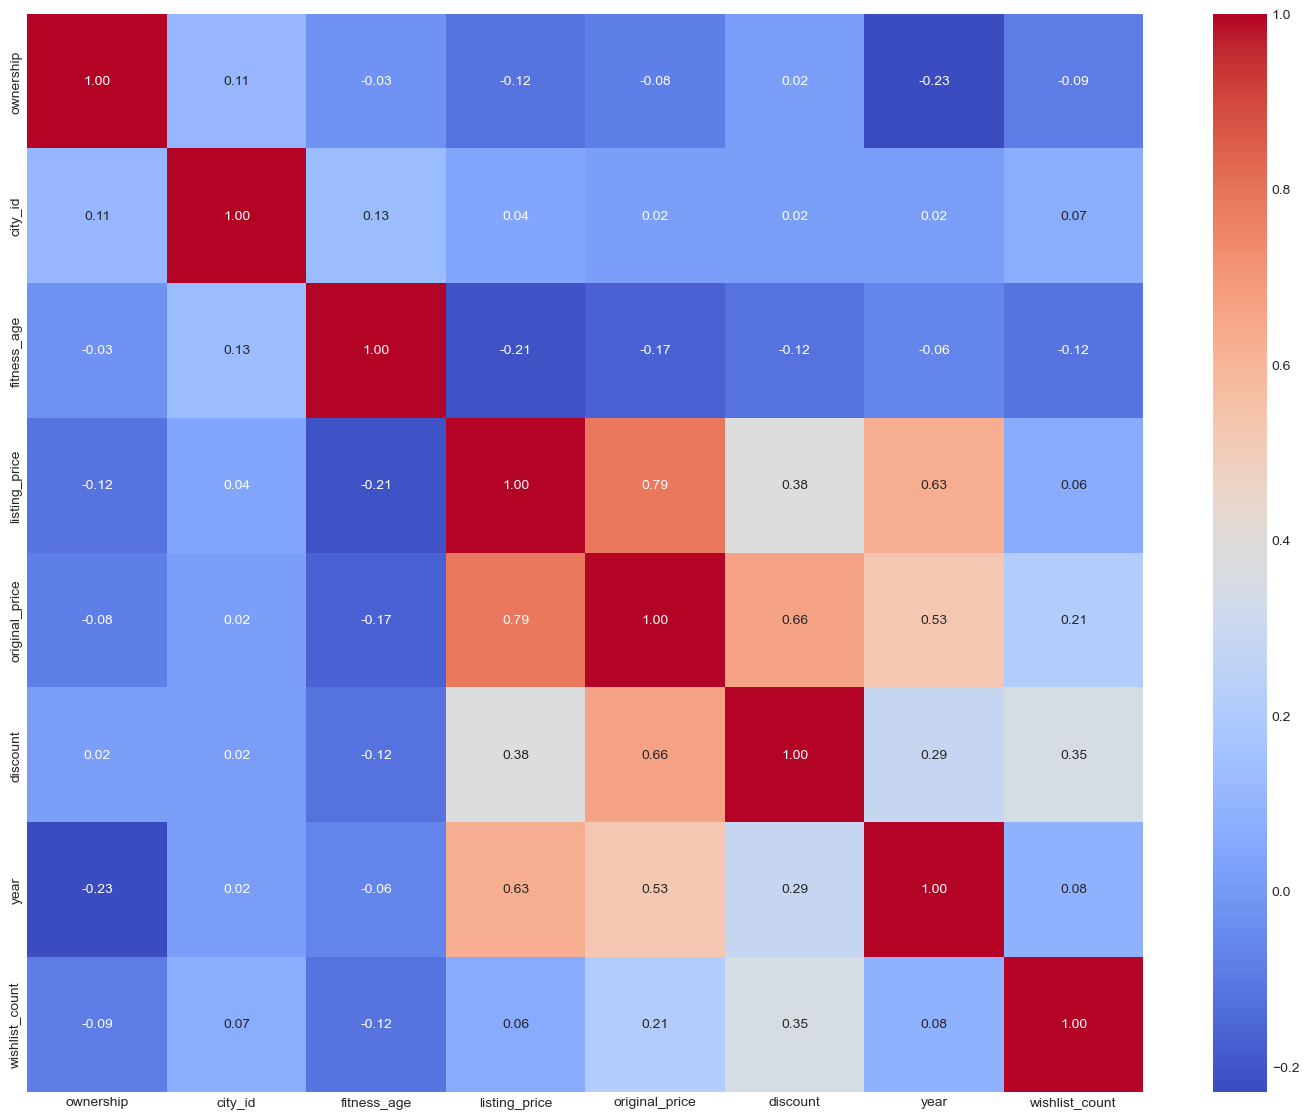

In [84]:
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [ ]:
#Bivariative Analysis

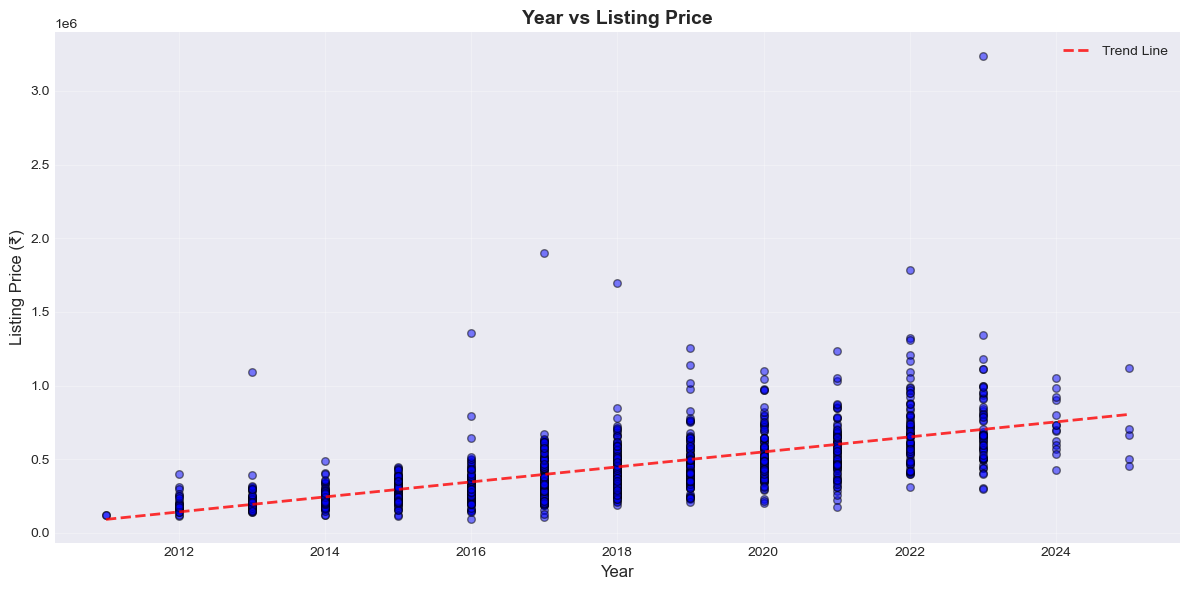

In [67]:
plt.figure(figsize=(12, 6))
plt.scatter(df['year'], df['listing_price'], alpha=0.5, s=30, color='blue', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Listing Price (₹)', fontsize=12)
plt.title('Year vs Listing Price', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
z = np.polyfit(df['year'], df['listing_price'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['year'].min(), df['year'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

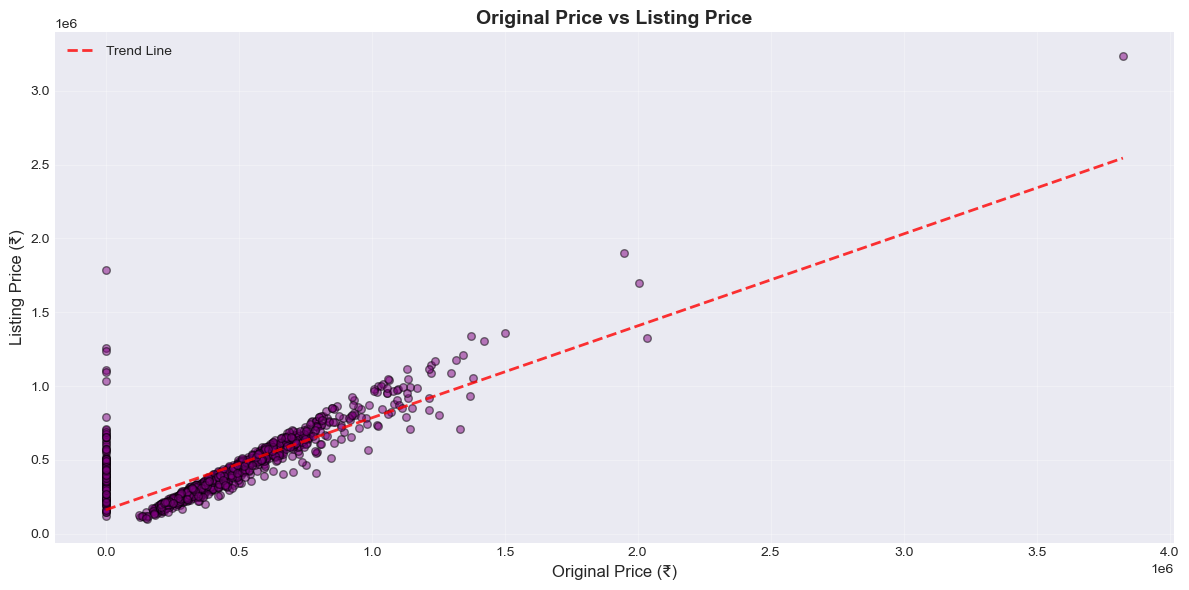

In [68]:
plt.figure(figsize=(12, 6))
plt.scatter(df['original_price'], df['listing_price'], alpha=0.5, s=30, color='purple', edgecolor='black')
plt.xlabel('Original Price (₹)', fontsize=12)
plt.ylabel('Listing Price (₹)', fontsize=12)
plt.title('Original Price vs Listing Price', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
# Add trend line
z = np.polyfit(df['original_price'], df['listing_price'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['original_price'].min(), df['original_price'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

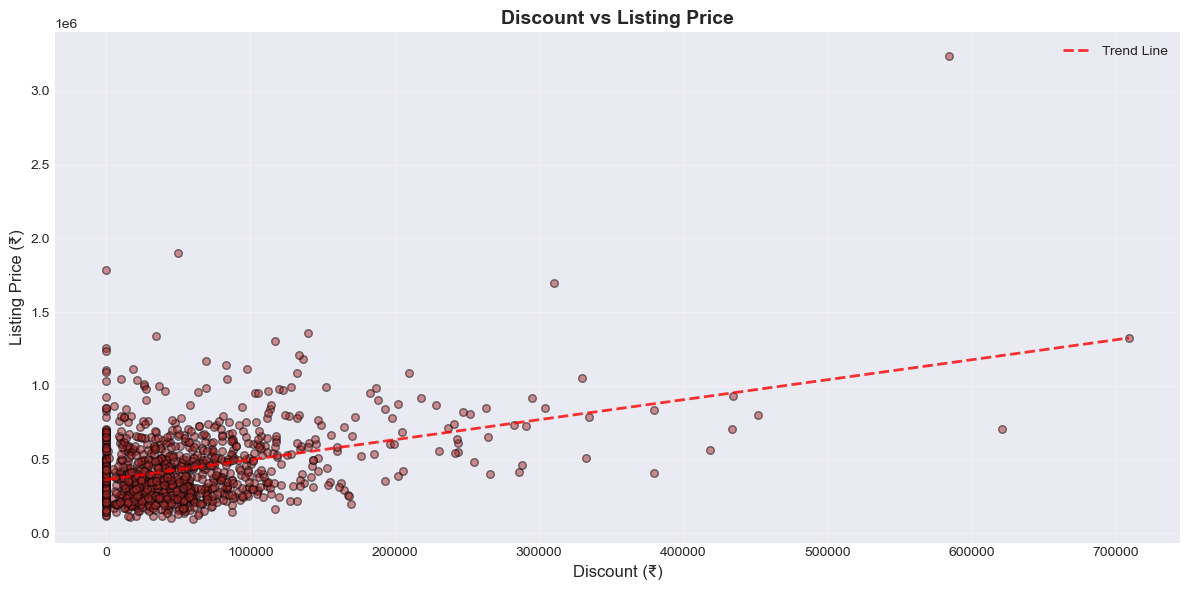

In [69]:
plt.figure(figsize=(12, 6))
plt.scatter(df['discount'], df['listing_price'], alpha=0.5, s=30, color='brown', edgecolor='black')
plt.xlabel('Discount (₹)', fontsize=12)
plt.ylabel('Listing Price (₹)', fontsize=12)
plt.title('Discount vs Listing Price', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
# Add trend line
valid_idx = df[['discount', 'listing_price']].dropna().index
if len(valid_idx) > 1:
    z = np.polyfit(df.loc[valid_idx, 'discount'], df.loc[valid_idx, 'listing_price'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df['discount'].min(), df['discount'].max(), 100)
    plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend Line')
    plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

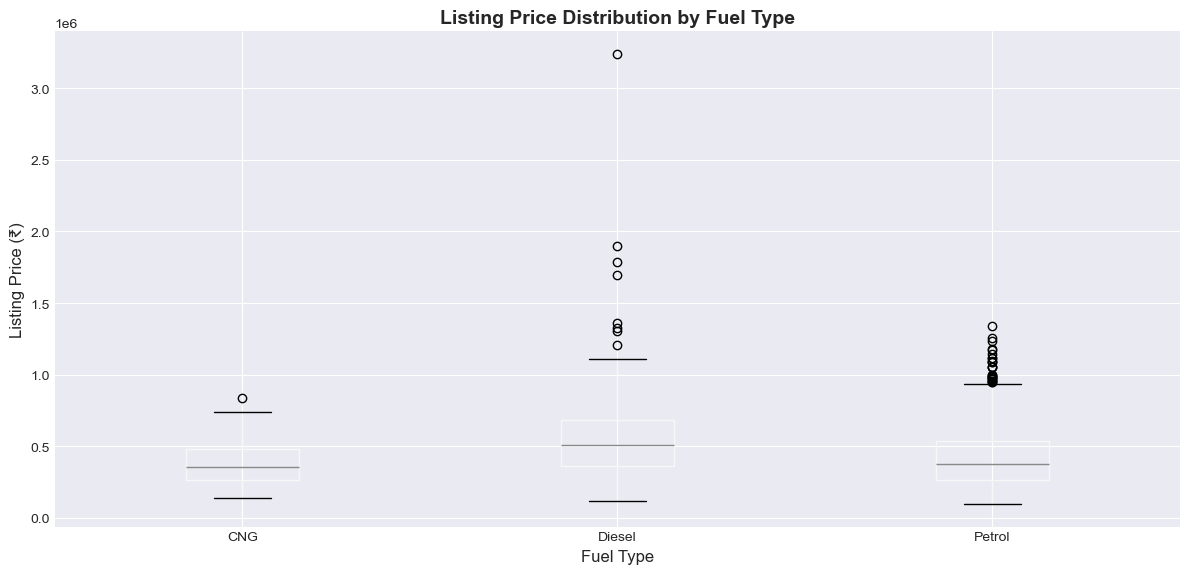

In [71]:
plt.figure(figsize=(12, 6))
df.boxplot(column='listing_price', by='fuel_type', figsize=(12, 6))
plt.suptitle('') 
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Listing Price (₹)', fontsize=12)
plt.title('Listing Price Distribution by Fuel Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#MultiVariative Analysis

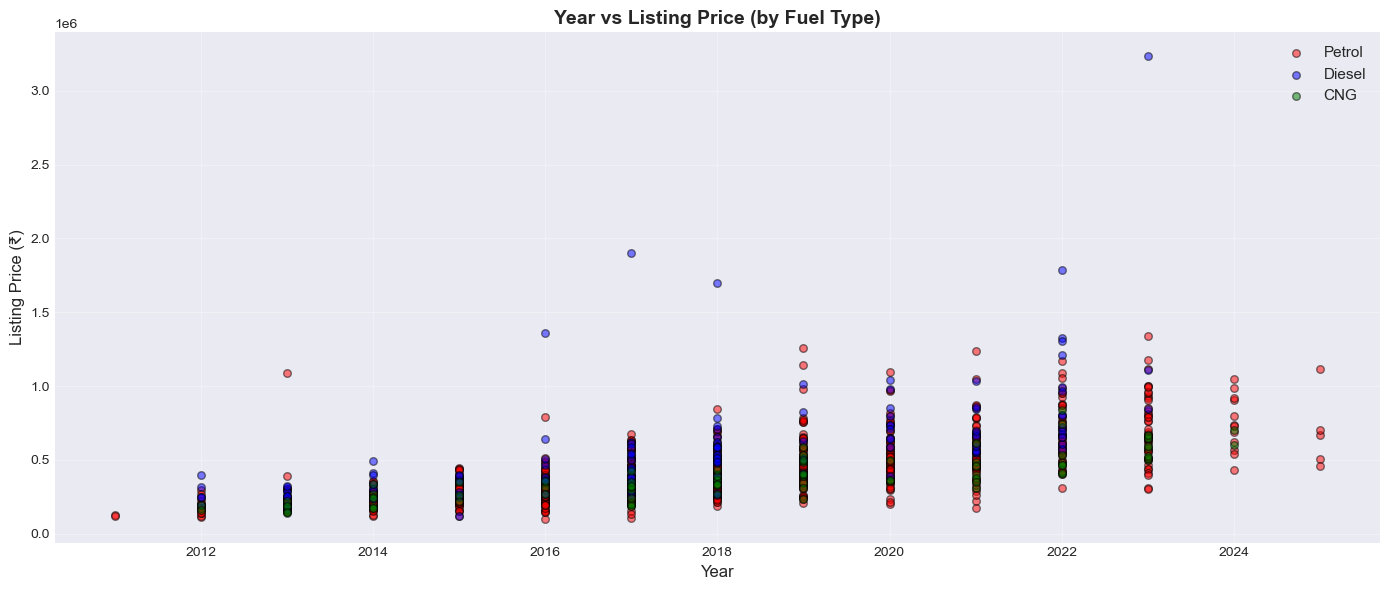

In [72]:
plt.figure(figsize=(14, 6))
petrol_df = df[df['fuel_type'] == 'Petrol']
diesel_df = df[df['fuel_type'] == 'Diesel']
cng_df = df[df['fuel_type'] == 'CNG']

plt.scatter(petrol_df['year'], petrol_df['listing_price'], alpha=0.5, s=30, 
           color='red', label='Petrol', edgecolor='black')
plt.scatter(diesel_df['year'], diesel_df['listing_price'], alpha=0.5, s=30, 
           color='blue', label='Diesel', edgecolor='black')
plt.scatter(cng_df['year'], cng_df['listing_price'], alpha=0.5, s=30, 
           color='green', label='CNG', edgecolor='black')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Listing Price (₹)', fontsize=12)
plt.title('Year vs Listing Price (by Fuel Type)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

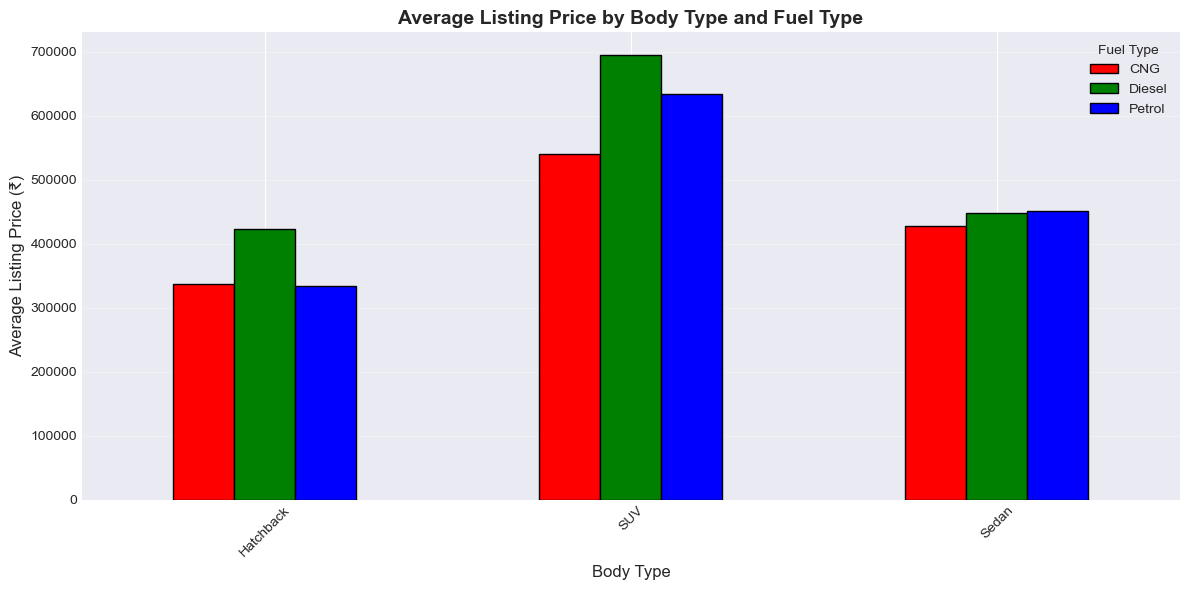

In [74]:
plt.figure(figsize=(12, 6))
body_fuel_price = pd.pivot_table(df, values='listing_price', index='body_type', columns='fuel_type', aggfunc='mean')
body_fuel_price.plot(kind='bar', ax=plt.gca(), color=['red', 'green', 'blue'], edgecolor='black')
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Average Listing Price (₹)', fontsize=12)
plt.title('Average Listing Price by Body Type and Fuel Type', fontsize=14, fontweight='bold')
plt.legend(title='Fuel Type', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

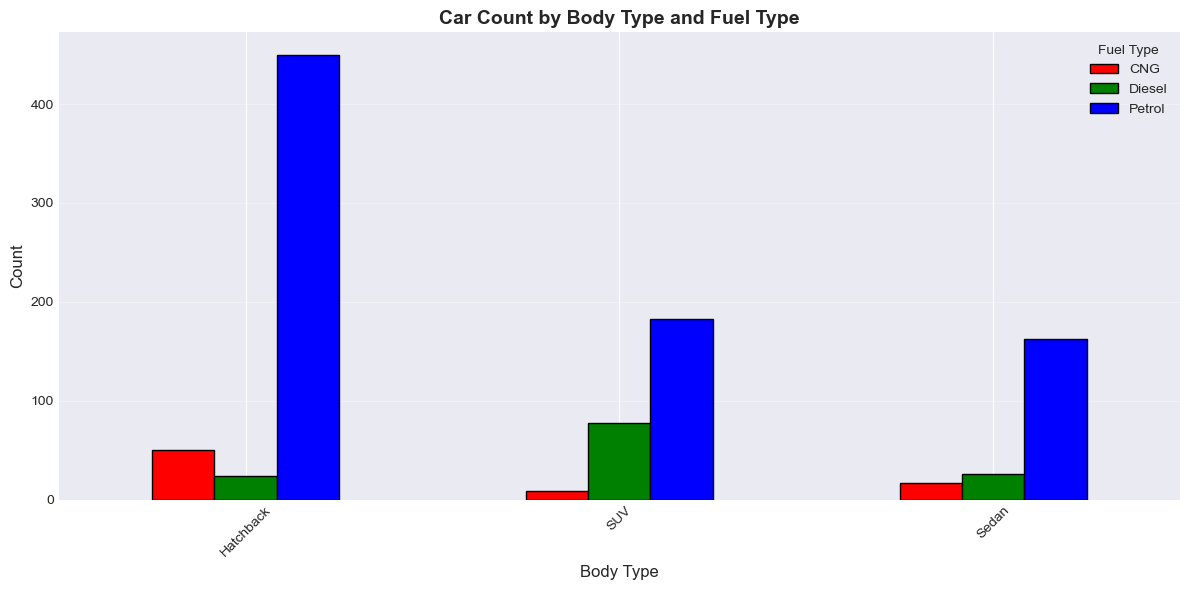

In [75]:
plt.figure(figsize=(12, 6))
body_fuel_count = pd.crosstab(df['body_type'], df['fuel_type'])
body_fuel_count.plot(kind='bar', ax=plt.gca(), color=['red', 'green', 'blue'], edgecolor='black')
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Car Count by Body Type and Fuel Type', fontsize=14, fontweight='bold')
plt.legend(title='Fuel Type', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

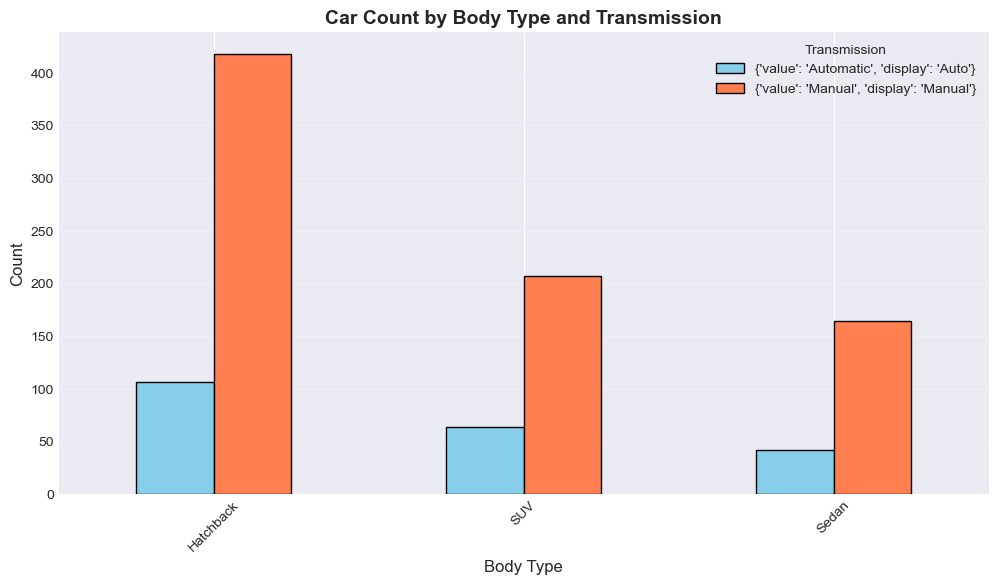

In [76]:
plt.figure(figsize=(12, 6))
body_trans_count = pd.crosstab(df['body_type'], df['transmission'])
body_trans_count.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'coral'], edgecolor='black')
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Car Count by Body Type and Transmission', fontsize=14, fontweight='bold')
plt.legend(title='Transmission', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

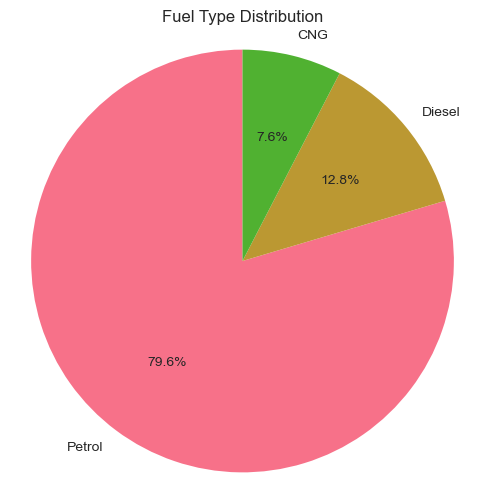

In [96]:
counts = df['fuel_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index,
        autopct='%1.1f%%', startangle=90)

plt.title('Fuel Type Distribution')
plt.axis('equal')  
plt.show()

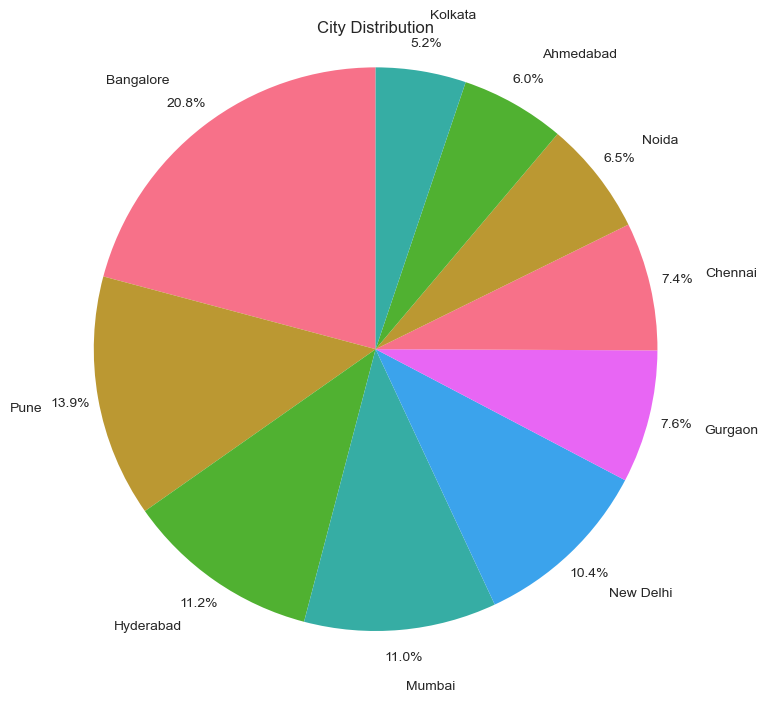

In [103]:
plt.figure(figsize=(8,8))

plt.pie(counts[:10],
        labels=counts[:10].index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=1.1,
        labeldistance=1.2)

plt.title('City Distribution')
plt.axis('equal')

plt.show()

In [97]:
df.columns

Index(['car_name', 'color', 'car_segment', 'ownership', 'city_id',
       'fitness_age', 'listing_price', 'original_price', 'discount', 'status',
       'year', 'transmission', 'odometer', 'body_type', 'fuel_type',
       'city_rto', 'wishlist_count', 'city_name'],
      dtype='object')